In [ ]:
# @title Kelompok 5 - TEMA 4: WAR KREDIBILITAS BRAND: E-COMMERCE & EKSPEDISI LOGISTIK

In [ ]:
# ==========================================
# @title 1. IMPORT LIBRARY
# ==========================================

!pip -q install Sastrawi wordcloud nltk emoji

import pandas as pd
import numpy as np
import re
import emoji
import nltk

import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

from wordcloud import WordCloud, STOPWORDS
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from nltk.tokenize import word_tokenize

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import TruncatedSVD, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

pd.set_option('display.max_colwidth', None)

print("Library berhasil diimport")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 20.8 MB/s eta 0:00:00
Library berhasil diimport


In [ ]:
# ==========================================
# @title 2. CRAWLING DATA E-COMMERCE & EKSPEDISI
# ==========================================

"""
Sumber Data : Twitter/X
Tools       : Tweet Harvest
Periode     : since:2025-01-01

File hasil crawling:
1. lazada_id.csv
2. tiktokshop_id.csv
3. jnt_id.csv
4. sicepat_id.csv

Data telah difilter menggunakan bahasa Indonesia.
"""

print("Sumber Data : Twitter/X")
print("Tools       : Tweet Harvest")
print("Periode     : since:2025-01-01")
print("Brand E-Commerce : Lazada, TikTok Shop")
print("Brand Ekspedisi  : J&T, SiCepat")

Sumber Data : Twitter/X
Tools       : Tweet Harvest
Periode     : since:2025-01-01
Brand E-Commerce : Lazada, TikTok Shop
Brand Ekspedisi  : J&T, SiCepat


In [ ]:
# ==========================================
# @title 3. LOAD DATASET
# ==========================================

import pandas as pd

# E-Commerce
df_lazada = pd.read_csv('/content/lazada_id.csv')
df_ttshop = pd.read_csv('/content/tiktokshop_id.csv')

# Ekspedisi
df_jnt = pd.read_csv('/content/jnt_id.csv')
df_sicepat = pd.read_csv('/content/sicepat_id.csv')

print("=== E-COMMERCE ===")
print("Lazada      :", len(df_lazada))
print("TikTok Shop :", len(df_ttshop))

print("\n=== EKSPEDISI ===")
print("J&T         :", len(df_jnt))
print("SiCepat     :", len(df_sicepat))

=== E-COMMERCE ===
Lazada      : 497
TikTok Shop : 472

=== EKSPEDISI ===
J&T         : 497
SiCepat     : 498


In [ ]:
# ==========================================
# @title 4. PENGGABUNGAN DATASET
# ==========================================

datasets = [
    (df_lazada, 'Lazada', 'E-Commerce'),
    (df_ttshop, 'TikTok Shop', 'E-Commerce'),
    (df_jnt, 'J&T', 'Ekspedisi'),
    (df_sicepat, 'SiCepat', 'Ekspedisi')]

for data, brand, kategori in datasets:
    data['brand'] = brand
    data['kategori'] = kategori

df = pd.concat(
    [x[0] for x in datasets],
    ignore_index=True)

df = df.drop_duplicates(subset=['full_text'])
df = df.dropna(subset=['full_text'])

print("Jumlah data gabungan:", len(df))

display(
    df['brand']
    .value_counts()
    .rename_axis('Brand')
    .reset_index(name='Jumlah Data'))

Jumlah data gabungan: 1905


,Brand,Jumlah Data
0,Lazada,497
1,SiCepat,497
2,J&T,496
3,TikTok Shop,415


In [ ]:
# ==========================================
# @title 5. DATA UNDERSTANDING
# ==========================================

print("Ukuran Dataset:", df.shape)

print("\nInformasi Dataset:")
display(df.info())

print("\nJumlah Data Kosong:")
display(df.isnull().sum())

print("\nJumlah Data Duplikat:")
print(df.duplicated().sum())

print("\nDistribusi Brand:")
display(df['brand'].value_counts())

print("\nDistribusi Kategori:")
display(df['kategori'].value_counts())

Ukuran Dataset: (1905, 17)

Informasi Dataset:
<class 'pandas.core.frame.DataFrame'>
Index: 1905 entries, 0 to 1963
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   conversation_id_str      1905 non-null   int64  
 1   created_at               1905 non-null   object 
 2   favorite_count           1905 non-null   int64  
 3   full_text                1905 non-null   object 
 4   id_str                   1905 non-null   int64  
 5   image_url                984 non-null    object 
 6   in_reply_to_screen_name  489 non-null    object 
 7   lang                     1905 non-null   object 
 8   location                 0 non-null      float64
 9   quote_count              1905 non-null   int64  
 10  reply_count              1905 non-null   int64  
 11  retweet_count            1905 non-null   int64  
 12  tweet_url                1905 non-null   object 
 13  user_id_str              1905 non-nu

None


Jumlah Data Kosong:


,0
conversation_id_str,0
created_at,0
favorite_count,0
full_text,0
id_str,0
image_url,921
in_reply_to_screen_name,1416
lang,0
location,1905
quote_count,0



Jumlah Data Duplikat:
0

Distribusi Brand:


,count
brand,
Lazada,497
SiCepat,497
J&T,496
TikTok Shop,415



Distribusi Kategori:


,count
kategori,
Ekspedisi,993
E-Commerce,912


/tmp/ipykernel_925/4091535709.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
/tmp/ipykernel_925/4091535709.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


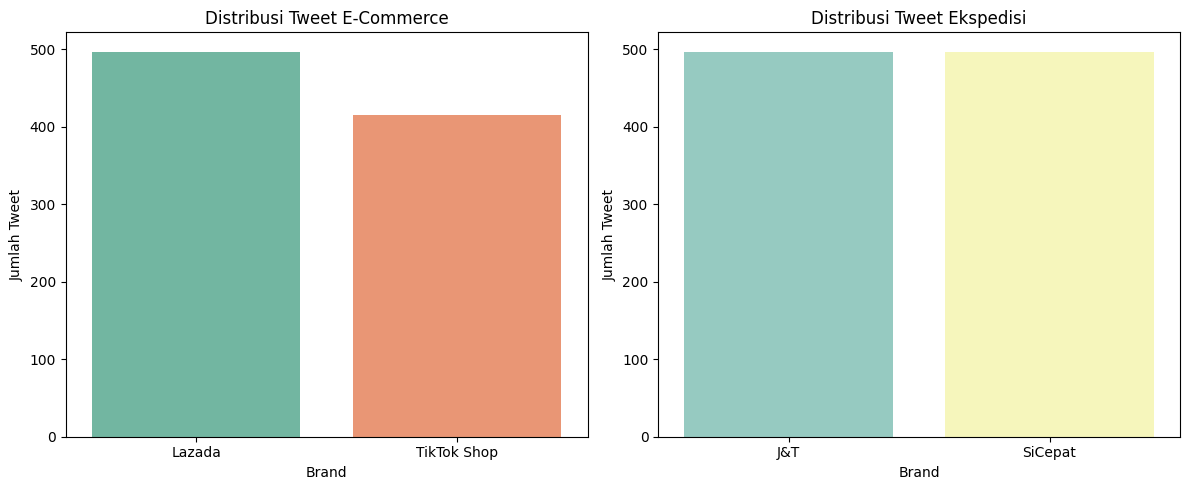

In [ ]:
# ==========================================
# @title 6. DISTRIBUSI DATA E-COMMERCE & EKSPEDISI
# ==========================================

fig, axes = plt.subplots(1, 2, figsize=(12,5))

# E-Commerce
sns.countplot(
    data=df[df['kategori']=='E-Commerce'],
    x='brand',
    ax=axes[0],
    palette='Set2')

axes[0].set_title('Distribusi Tweet E-Commerce')
axes[0].set_xlabel('Brand')
axes[0].set_ylabel('Jumlah Tweet')

# Ekspedisi
sns.countplot(
    data=df[df['kategori']=='Ekspedisi'],
    x='brand',
    ax=axes[1],
    palette='Set3')

axes[1].set_title('Distribusi Tweet Ekspedisi')
axes[1].set_xlabel('Brand')
axes[1].set_ylabel('Jumlah Tweet')

plt.tight_layout()
plt.show()

In [ ]:
# ==========================================
# @title 7. PREPROCESSING TEXT
# ==========================================

!pip -q install emoji nltk

import re, emoji, nltk, pandas as pd
from nltk.tokenize import word_tokenize

nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

kamus_alay = {
    "ga":"tidak","gak":"tidak","gk":"tidak","nggak":"tidak","tdk":"tidak","tak":"tidak","cs":"customer_service","cust":"customer","sellerku":"seller","sellernya":"seller",
    "bgt":"banget","bgtt":"banget","bangettt":"banget","udh":"sudah","sdh":"sudah","gajelas":"tidak_jelas","ga jelas":"tidak_jelas","lemot":"lambat",
    "tp":"tapi","jd":"jadi","lg":"lagi","yg":"yang","klo":"kalau","kl":"kalau", "sampe":"sampai","nyampe":"sampai","nyampek":"sampai","dikirim2":"dikirim",
    "buyer":"pembeli","paketku":"paket","paketnya":"paket","kurirnya":"kurir","tokped":"tokopedia","ttshop":"tiktokshop","tiktok shop":"tiktokshop",
    "spx":"shopee_express","shopee express":"shopee_express","jnt":"jnt_express","j&t":"jnt_express","jne":"jne_express","sicepat":"sicepat_express"}

negasi = ["tidak","bukan","tak","belum"]

def full_preprocessing(text):
    if not isinstance(text, str): return "", []
    text = text.lower().strip()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    text = re.sub(r'@\w+|#\w+', '', text)
    text = emoji.demojize(text, delimiters=("", ""))
    text = re.sub(r'[^\w\s]', ' ', text)
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)

    for slang, normal in kamus_alay.items():
        text = re.sub(r'\b' + re.escape(slang) + r'\b', normal, text)

    tokens = text.split()
    for i in range(len(tokens)-1):
        if tokens[i] in negasi:
            tokens[i] = tokens[i] + "_" + tokens[i+1]
            tokens[i+1] = ""

    text = " ".join([t for t in tokens if t])
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if len(t) > 1]

    return text, tokens

df[['clean_text','tokens']] = df['full_text'].apply(
    lambda x: pd.Series(full_preprocessing(x)))

print("Preprocessing selesai")
df[['brand','kategori','full_text','clean_text']].sample(10)

Preprocessing selesai


,brand,kategori,full_text,clean_text
1184,J&T,Ekspedisi,"Hi, J&amp;T Friends! Selain bagi-bagi THR, di Ramadan kali ini J&amp;T Express juga bersilaturahmi dengan teman-teman UMKM binaan Rumah BUMN untuk memberikan pelatihan dengan tema ""Kenalan dengan Social Commerce dan Webstore untuk Tingkatin Penjualan.""\n\nAcara jadi makin seru karena https://t.co/rAm2CLrAmb",hi j amp t friends selain bagi bagi thr di ramadan kali ini j amp t express juga bersilaturahmi dengan teman teman umkm binaan rumah bumn untuk memberikan pelatihan dengan tema kenalan dengan social commerce dan webstore untuk tingkatin penjualan acara jadi makin seru karena
1944,SiCepat,Ekspedisi,"Kesel banget kurir si cepat, kurirnya beda bukan langganan. Terus antara libur atau gimana, jadi alhasil cuma 1 kurir anjirrr. Kalau kek gini ya sampe maghrib",kesel banget kurir si cepat kurir beda bukan_langganan terus antara libur atau gimana jadi alhasil cuma 1 kurir anjirr kalau kek gini ya sampai maghrib
406,Lazada,E-Commerce,"@NQza17 Halo Bapak/Ibu, Admin mohon maaf atas kendala yang Bapak/Ibu alami saat ini, perihal kendala yang dialami Bapak/Ibu bisa informasikan keluhannya dengan mencoba kembali menghubungi DM dengan menginformasikan data kepelangganannya agar bisa Admin bantu ya Pak/Bu. Terima Kasih.*NF",halo bapak ibu admin mohon maaf atas kendala yang bapak ibu alami saat ini perihal kendala yang dialami bapak ibu bisa informasikan keluhannya dengan mencoba kembali menghubungi dm dengan menginformasikan data kepelangganannya agar bisa admin bantu ya pak bu terima kasih nf
935,TikTok Shop,E-Commerce,"Pemerintah Taiwan menyatakan, proses peninjauan internal di Amerika Serikat terkait penjualan paket senjata baru untuk mereka masih berjalan sesuai jadwal, meskipun situasi geopolitik global tengah memanas.\n\nBaca di: https://t.co/SdDiQyLXic \n\n~WR #Taiwan #Trump #Amerika https://t.co/zndZesHLuj",pemerintah taiwan menyatakan proses peninjauan internal di amerika serikat terkait penjualan paket senjata baru untuk mereka masih berjalan sesuai jadwal meskipun situasi geopolitik global tengah memanas baca di wr
557,TikTok Shop,E-Commerce,"""Saat dilaksanakan pemeriksaan makanan ditemukan plastik kecil yang diduga narkoba jenis sabu di dalam tulang dan di dalam daging ayam bagian ceker, paha atas dan sayap dengan jumlah 10 paket dengan ukuran berbeda beda,"" ujar Kepala Lapas Narkotika Jakarta, Syarpani.\n\n👉🏻Baca https://t.co/yGLVfpCaey",saat dilaksanakan pemeriksaan makanan ditemukan plastik kecil yang diduga narkoba jenis sabu di dalam tulang dan di dalam daging ayam bagian ceker paha atas dan sayap dengan jumlah 10 paket dengan ukuran berbeda beda ujar kepala lapas narkotika jakarta syarpani backhand_index_pointing_right_light_skin_tonebaca
341,Lazada,E-Commerce,Komputer rusak garap komis di warnet https://t.co/53tCnl42L1,komputer rusak garap komis di warnet
425,Lazada,E-Commerce,"Ini kenapa listrik sering mati, gak ada konferensi pers dari pihak PLN atau pemerintah. Banyak banget yang di rugikan terutama mungkin harus siap siap barang elektronik nya rusak",ini kenapa listrik sering mati tidak_ada konferensi pers dari pihak pln atau pemerintah banyak banget yang di rugikan terutama mungkin harus siap siap barang elektronik nya rusak
1706,SiCepat,Ekspedisi,"kata gue cepat balik nu, si bungsu semakin didepan https://t.co/lFdj4HiEUS",kata gue cepat balik nu si bungsu semakin didepan
65,Lazada,E-Commerce,"Ironi Kasat Narkoba Toraja Utara, Dulu Garang Ringkus Nakes Kurir Sabu, Kini Terjerat ""Nyanyian"" Bandar ~SN\n\nKlik untuk baca: https://t.co/RzfrnzCr0i",ironi kasat narkoba toraja utara dulu garang ringkus nakes kurir sabu kini terjerat nyanyian bandar sn klik untuk baca
1503,SiCepat,Ekspedisi,"Di mata kami, kamu selalu menjadi si bungsu yang harus dijaga.\nNamun waktu ternyata berjalan jauh lebih cepat daripada yang kita sadari."" Bibirnya mengatup, ada rasa emosional dalam dirinya saat ini.",di mata kami kamu selalu menjadi si bungsu yang harus dijaga namun wak

In [ ]:
# ==========================================
# @title 8. FREKUENSI KELUHAN PENGGUNA
# ==========================================

keluhan = {
    "Paket belum sampai ke alamat": [
        "belum sampai","paket belum","tidak sampai"],

    "Paket diterima dalam kondisi rusak": [
        "rusak","pecah","barang rusak"],

    "Pengiriman paket sangat terlambat": [
        "telat","terlambat","lama","stuck"],

    "Kurir tidak menghubungi penerima": [
        "kurir","cod","resi"],

    "Proses refund belum diproses": [
        "refund","retur"],

    "Voucher atau promo tidak berlaku": [
        "voucher","promo","diskon"],

    "Aplikasi mengalami gangguan sistem": [
        "aplikasi","error"]}

hasil = []

for kategori, keywords in keluhan.items():
    jumlah = df["clean_text"].str.contains(
        "|".join(keywords),
        case=False,
        na=False).sum()

    hasil.append([kategori, jumlah])

isu_df = pd.DataFrame(
    hasil,
    columns=["Keluhan", "Jumlah"])

isu_df = isu_df.sort_values(
    "Jumlah",
    ascending=False)

display(isu_df)

,Keluhan,Jumlah
2,Pengiriman paket sangat terlambat,317
3,Kurir tidak menghubungi penerima,249
1,Paket diterima dalam kondisi rusak,116
4,Proses refund belum diproses,88
5,Voucher atau promo tidak berlaku,87
6,Aplikasi mengalami gangguan sistem,62
0,Paket belum sampai ke alamat,3


/tmp/ipykernel_925/3736977321.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_925/3736977321.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


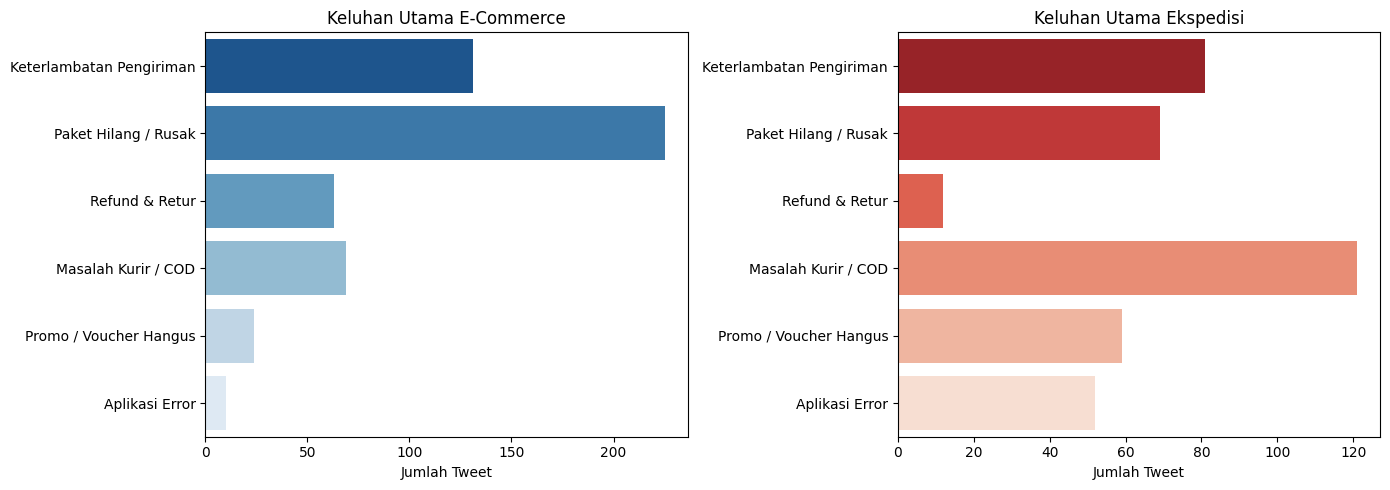

In [ ]:
# ==========================================
# @title 9. PERBANDINGAN ISU E-COMMERCE VS EKSPEDISI
# ==========================================

issue_mapping = {
    'Keterlambatan Pengiriman': ['telat','terlambat','lama','pengiriman','stuck'],
    'Paket Hilang / Rusak': ['hilang','rusak','barang'],
    'Refund & Retur': ['refund','retur'],
    'Masalah Kurir / COD': ['kurir','cod','resi'],
    'Promo / Voucher Hangus': ['promo','voucher','diskon'],
    'Aplikasi Error': ['aplikasi','error']}

hasil = []

for kategori in ['E-Commerce','Ekspedisi']:
    subset = df[df['kategori'] == kategori]
    for isu, keywords in issue_mapping.items():

        pattern = '|'.join(
            [rf'\b{k}\b' for k in keywords])

        jumlah = subset['clean_text'].str.contains(
            pattern,
            case=False,
            na=False).sum()

        hasil.append([kategori, isu, jumlah])

issue_df = pd.DataFrame(
    hasil,
    columns=['Kategori','Isu','Jumlah'])

fig, axes = plt.subplots(1, 2, figsize=(14,5))

# E-Commerce
sns.barplot(
    data=issue_df[issue_df['Kategori']=='E-Commerce'],
    x='Jumlah',
    y='Isu',
    palette='Blues_r',
    ax=axes[0])

axes[0].set_title('Keluhan Utama E-Commerce')
axes[0].set_xlabel('Jumlah Tweet')
axes[0].set_ylabel('')

# Ekspedisi
sns.barplot(
    data=issue_df[issue_df['Kategori']=='Ekspedisi'],
    x='Jumlah',
    y='Isu',
    palette='Reds_r',
    ax=axes[1])

axes[1].set_title('Keluhan Utama Ekspedisi')
axes[1].set_xlabel('Jumlah Tweet')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

In [ ]:
# ==========================================
# @title 9B. PERBANDINGAN ISU E-COMMERCE VS EKSPEDISI
# ==========================================

import pandas as pd

issue_mapping = {
    'Keterlambatan Pengiriman': [
        'paket telat','pengiriman lama','belum sampai','paket belum','kurir lama','status stuck'],

    'Paket Hilang / Rusak': [
        'paket hilang','barang rusak','paket rusak','barang pecah'],

    'Refund & Retur': [
        'minta refund','tidak bisa refund','paket retur','proses refund'],

    'Masalah Kurir / COD': [
        'kurir','cod','gagal kirim','alamat tidak ditemukan'],

    'Promo / Voucher': [
        'voucher','diskon','promo'],

    'Aplikasi Error': [
        'aplikasi lemot','aplikasi error','notifikasi delay','upload produk']}

kata_keluhan = [
    "komplain", "ngeluh", "kecewa", "parah","gak", "tidak", "ga", "banget",
    "retur", "refund", "hilang", "rusak","telat", "lama", "stuck",
    "belum", "gagal", "masalah","error", "lemot", "cancel"]

contoh = []
for isu, keywords in issue_mapping.items():
    pattern_isu = '|'.join(
        [rf'\b{k}\b' for k in keywords])

    pattern_keluhan = '|'.join(
        [rf'\b{k}\b' for k in kata_keluhan])

    subset = df[
        (df["full_text"].str.contains(
            '|'.join(keywords),
            case=False,
            na=False))
        &
        (df["full_text"].str.contains(
            pattern_keluhan,
            case=False,
            na=False))]

    sample = subset["full_text"].drop_duplicates().head(3)

    for text in sample:
        text = text.replace("\n", " ")
        text = text[:220]

        contoh.append([
            isu,
            text + "..."])

contoh_df = pd.DataFrame(
    contoh,
    columns=["Isu", "Contoh Keluhan"])

display(contoh_df)

,Isu,Contoh Keluhan
0,Keterlambatan Pengiriman,"@ziwonist_ @ShopeeCare Hi kak ziwonist_ , maaf bikin kk resah terkait pesanan belum sampai. Krna sdg trjadi peningktan jmlh psnn, shg butuh wktu lbh utk mengirim pesanan. Untuk pengecekan lebih lanjut boleh infokan no pe..."
1,Keterlambatan Pengiriman,Halo @jntexpressid paket saya diinfokan sudah sampai padahal 1. Belum sampai 2. Barang yang difoto bukan paket saya Tolong dong....
2,Keterlambatan Pengiriman,"@jntexpressid min, paket saya udah 4 hari belum sampai2. Saya harus hubungi kemana ini? Masa sampai sini doang? https://t.co/gL8HzGYhtI..."
3,Paket Hilang / Rusak,@jntexpressid @tokopedia Pernah juga ngerasain paket hilang https://t.co/FI2PBz1j7x...
4,Paket Hilang / Rusak,Viral Bobby Nasution bagikan bantuan dari helikopter hingga banyak paket rusak saat mendarat. Puan mendorong evaluasi agar distribusi bantuan lebih efektif. https://t.co/BVUGvz6nrH...
5,Paket Hilang / Rusak,"JO0324561543 paket stuck dari tgl 4, minta push pengiriman tetep aja masih stuck dibalaraja. Mohon buatkan laporan untuk resi tsb. Klo emg paket hilang tolong diupdate, biar bisa proses refund. @jntexpressid https://t.c..."
6,Refund & Retur,"Ada customer di grabfood, cuma mesen ayam goreng tanpa nasi, tapi karyawanku salah packing. Dibungkusnya ayam goreng pake nasi. Si customer tetep dapet Ayamnya✅ malah jadi bonus nasi. Eeh, yg bikin kagetnya, dia minta re..."
7,Refund & Retur,"halo gaiss update terbaruu, tolong bantu di upp, trnyata list nambah panjang dan proses refund masih stuck itu2 aja, aku cuma bisa bantu spill di x gini dan berdoa smg cpt clear buat para korban + gaada korban selanjutny..."
8,Refund & Retur,"tadi malem kaget kecil karena tiba-tiba spay kepotong 120k buat perpanjang netflix.. aku gatau kalo membershipnya auto renew di web wkwk. krn bukan subscription lewat app store, jadi gabisa ask refund di web apple. detik..."
9,Masalah Kurir / COD,"Sebel banget ada paket diretur alasannya karena alamat kurang jelas, padahal ada 2 paket yang alamat + no hp nya sama persis tapi bisa nyampe dengan selamat 😭😭 Pas dicek di resinya keliatan kalau kurirnya yang salah so..."


,Isu,Jumlah
3,Paket Hilang / Rusak,294
1,Keterlambatan Pengiriman,212
2,Masalah Kurir / COD,190
4,Promo / Voucher Hangus,83
5,Refund & Retur,75
0,Aplikasi Error,62


/tmp/ipykernel_925/2626067996.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


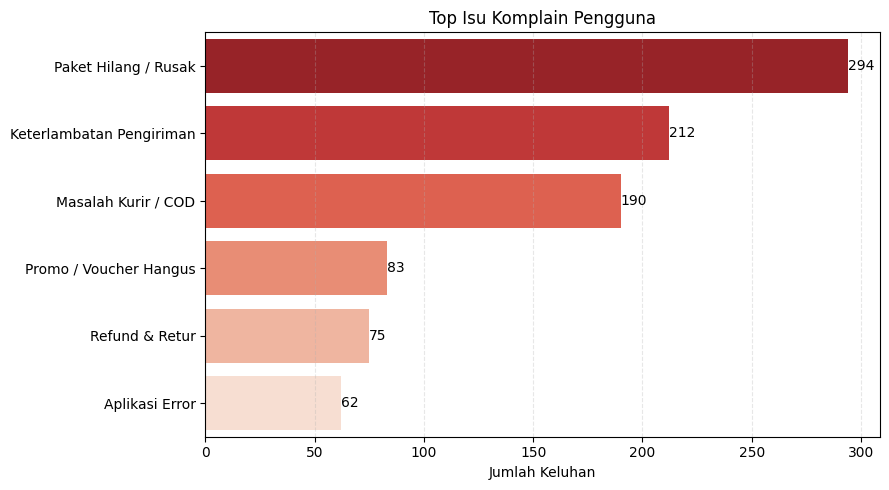

In [ ]:
# ==========================================
# @title 10. TOP ISU KOMPLAIN TERBANYAK
# ==========================================

top_issue = (
    issue_df.groupby('Isu')['Jumlah']
    .sum()
    .reset_index()
    .sort_values('Jumlah', ascending=False))

display(top_issue)

plt.figure(figsize=(9,5))

ax = sns.barplot(
    data=top_issue,
    x='Jumlah',
    y='Isu',
    palette='Reds_r')

for i in ax.containers:
    ax.bar_label(i)

plt.title('Top Isu Komplain Pengguna')
plt.xlabel('Jumlah Keluhan')
plt.ylabel('')
plt.grid(axis='x', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# ==========================================
# @title 11. SENTIMENT ANALYSIS MENGGUNAKAN INSET LEXICON
# ==========================================

pos = pd.read_csv('/content/positive.tsv', sep='\t')
neg = pd.read_csv('/content/negative.tsv', sep='\t')

lexicon = {}

for word, weight in zip(pos['word'], pos['weight']):
    lexicon[word] = int(weight)

for word, weight in zip(neg['word'], neg['weight']):
    lexicon[word] = int(weight)

def labeling_inset(text):
    score = 0
    words = text.split()

    for i in range(len(words)-1):
        bigram = words[i] + " " + words[i+1]

        if bigram in lexicon:
            score += lexicon[bigram]

    for word in words:
        if word in lexicon:
            score += lexicon[word]

    if score > 0:
        return score, "Positif"
    elif score < 0:
        return score, "Negatif"
    else:
        return score, "Netral"

hasil_sentimen = df['clean_text'].apply(labeling_inset)

df['Sentiment_Score'] = hasil_sentimen.apply(lambda x: x[0])
df['Sentiment'] = hasil_sentimen.apply(lambda x: x[1])

display(df['Sentiment'].value_counts())

df[['brand','kategori','clean_text','Sentiment_Score','Sentiment']].sample(10)

,count
Sentiment,
Negatif,1520
Positif,338
Netral,47


,brand,kategori,clean_text,Sentiment_Score,Sentiment
1842,SiCepat,Ekspedisi,dahsyat kan kita org malaysia pasal sultan amp raja melayu bukan_main hangat jadi isu dari pagi sampai la tidak_abis tapi masa penyangak agama mencela sahabat nabi dia pertahankan sepenuh nyawa lepas tu nak tutup isu tu cepat² celakalah kalian yang mempertahankan si pengeji,-47,Negatif
527,TikTok Shop,E-Commerce,viral begal todongkan pisau ke kurir yang berteduh di bandung bawa kabur motor dan 12 paket,-14,Negatif
124,Lazada,E-Commerce,warga pulau maratua kabupaten berau kalimantan timur kini menghadapi krisis layanan kesehatan warga kecewa tidak_ada dokter di pulau berpenduduk 3 500 jiwa itu sejak 15 januari 2025,0,Netral
1779,SiCepat,Ekspedisi,semakin public punya keberanian tuk mem broadcast jati diri si manusia gorong gorong dg data dan fakta yang actual valid maka cepat atau lambat barrier yang selama ini mem protected sedemikan kuat nya insyaallah tumbangdouble_exclamation_markpalms_up_togetherred_heartIndonesiaraised_fist,-12,Negatif
1553,SiCepat,Ekspedisi,buat bulan ini masih avail hari ini dst karena kamu not in rush jadi bisa pilih tanggalnya ya cantik pelan pelan aja tapi kalau lebih cepat ketemu kamunya bersyukur bisa cepet cepet peluk cium sayang sayang si cantik buat carrd bisa kamu cek di pinned see you,-18,Negatif
474,Lazada,E-Commerce,dulu disebut laut naik ke darat dan desa hilang sekarang kita menyebutnya tsunami tapi tetap saja membangun terlalu dekat pantai ini soal kurang paham teknologi atau kita yang sengaja mengabaikan peringatan para leluhur,-24,Negatif
159,Lazada,E-Commerce,semoga beneran direalisasiin yaface_holding_back_tears soalnya banyak orang yang masih capable buat kerja tapi kepentok umur jadi tidak_ada lagi perasaan telat mulai melting_face,-14,Negatif
997,J&T,Ekspedisi,aku salah fokus dibagian chat jnt_express yang batas pengisian data maksimal 2x24jam jika melebihi batas akan dicancel claim gila segitunya ya pengen lari dari tanggung jawab sampai ngasih batas waktu 2hari ngga sebanding sama aku yang harus nunggu kepastian paket 2minggu lebih,-55,Negatif
289,Lazada,E-Commerce,buat yang mau kerja di jepang tolong banget biasakan disiplin dari sekarang guys kerja sama orang jepang beda banget sama di indonesia soal waktu dan kedisiplinan Japan jepang datang ke perusahaan lebih awal chourei 朝礼 apel pagi tepat waktu deadline keras telat,-3,Negatif
1149,J&T,Ekspedisi,saran saya hati hati kirim paket lewat paket dikirim sudah 3 minggu entah dimana apa di embat ya hilang bilang hilang masa 3 minggu dlm perjalanan jasa kirim apaan ini no jx5008369985,-17,Negatif


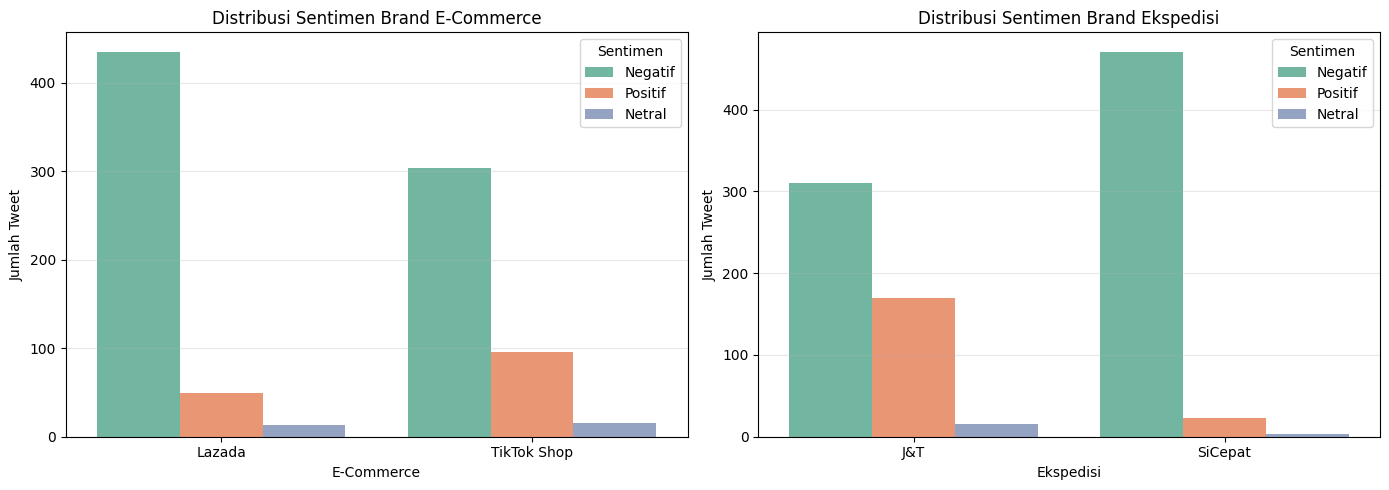

In [ ]:
# ==========================================
# @title 12. VISUALISASI SENTIMEN PER BRAND
# ==========================================

fig, axes = plt.subplots(1, 2, figsize=(14,5))

# E-Commerce
sns.countplot(
    data=df[df['kategori']=='E-Commerce'],
    x='brand',
    hue='Sentiment',
    palette='Set2',
    ax=axes[0])

axes[0].set_title('Distribusi Sentimen Brand E-Commerce')
axes[0].set_xlabel('E-Commerce')
axes[0].set_ylabel('Jumlah Tweet')
axes[0].grid(axis='y', alpha=0.3)
axes[0].legend(title='Sentimen')

# Ekspedisi
sns.countplot(
    data=df[df['kategori']=='Ekspedisi'],
    x='brand',
    hue='Sentiment',
    palette='Set2',
    ax=axes[1])

axes[1].set_title('Distribusi Sentimen Brand Ekspedisi')
axes[1].set_xlabel('Ekspedisi')
axes[1].set_ylabel('Jumlah Tweet')
axes[1].grid(axis='y', alpha=0.3)
axes[1].legend(title='Sentimen')

plt.tight_layout()
plt.show()


MODEL : Naive Bayes | FITUR : TF-IDF
Accuracy          : 0.8268
F1-Score Macro    : 0.4246
F1-Score Weighted : 0.7850

Classification Report:
              precision    recall  f1-score   support

     Negatif       0.83      0.98      0.90       304
      Netral       0.00      0.00      0.00         9
     Positif       0.74      0.25      0.37        68

    accuracy                           0.83       381
   macro avg       0.52      0.41      0.42       381
weighted avg       0.80      0.83      0.79       381



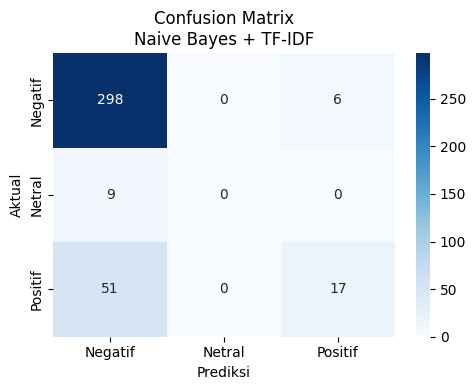


MODEL : SVM | FITUR : TF-IDF
Accuracy          : 0.7874
F1-Score Macro    : 0.4742
F1-Score Weighted : 0.7930

Classification Report:
              precision    recall  f1-score   support

     Negatif       0.90      0.84      0.87       304
      Netral       0.00      0.00      0.00         9
     Positif       0.47      0.66      0.55        68

    accuracy                           0.79       381
   macro avg       0.46      0.50      0.47       381
weighted avg       0.81      0.79      0.79       381



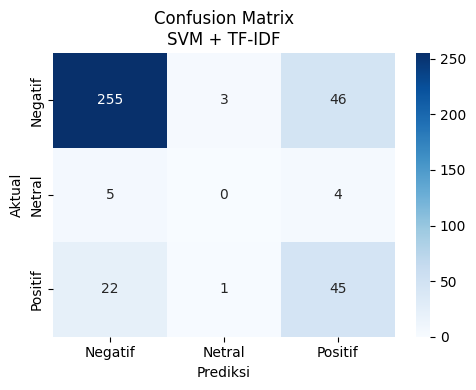


MODEL : KNN | FITUR : TF-IDF
Accuracy          : 0.7402
F1-Score Macro    : 0.4334
F1-Score Weighted : 0.7559

Classification Report:
              precision    recall  f1-score   support

     Negatif       0.87      0.87      0.87       304
      Netral       0.05      0.33      0.09         9
     Positif       0.75      0.22      0.34        68

    accuracy                           0.74       381
   macro avg       0.56      0.47      0.43       381
weighted avg       0.83      0.74      0.76       381



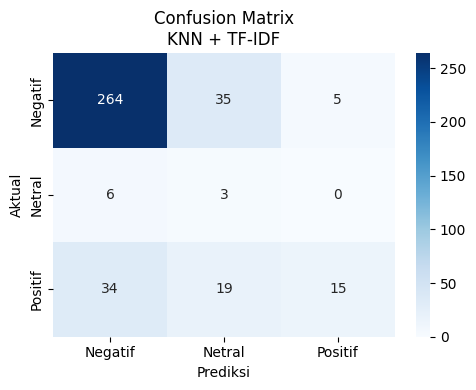


MODEL : XGBoost | FITUR : TF-IDF
Accuracy          : 0.8268
F1-Score Macro    : 0.4692
F1-Score Weighted : 0.8081

Classification Report:
              precision    recall  f1-score   support

     Negatif       0.86      0.94      0.90       304
      Netral       0.00      0.00      0.00         9
     Positif       0.60      0.44      0.51        68

    accuracy                           0.83       381
   macro avg       0.49      0.46      0.47       381
weighted avg       0.80      0.83      0.81       381



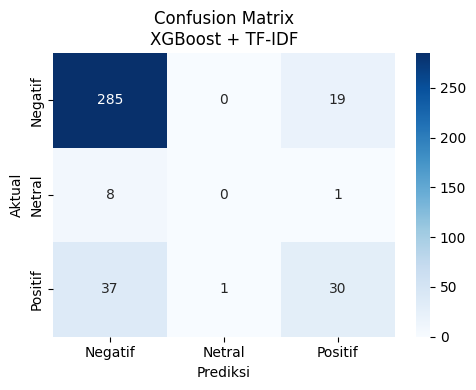

,Model,Accuracy,F1_Macro,F1_Weighted
3,XGBoost,0.826772,0.469176,0.808106
1,SVM,0.787402,0.474151,0.792964
0,Naive Bayes,0.826772,0.424643,0.785035
2,KNN,0.740157,0.433413,0.755906


/tmp/ipykernel_925/315800911.py:95: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


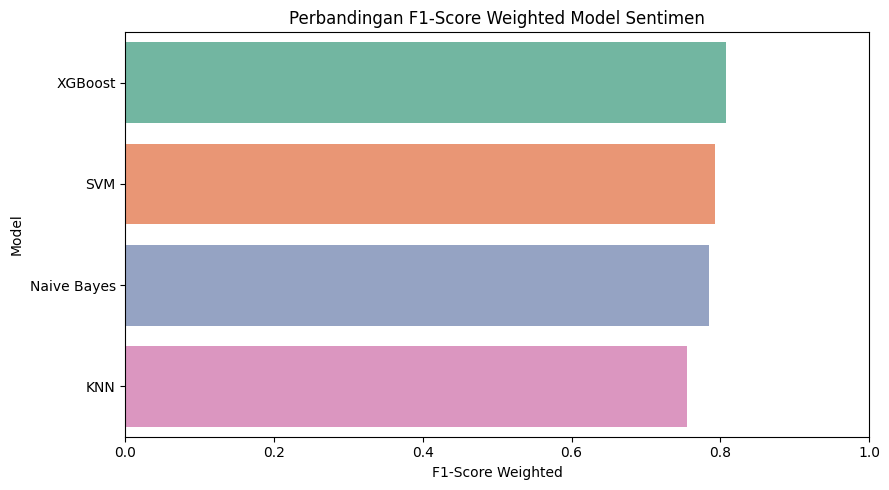

In [ ]:
# ==========================================
# @title 13. EVALUASI KLASIFIKASI SENTIMEN — TF-IDF
# ==========================================

!pip -q install xgboost

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

df_model = df.dropna(subset=['clean_text','Sentiment']).copy()

X = df_model['clean_text']
y = df_model['Sentiment']

le = LabelEncoder()
y_enc = le.fit_transform(y)

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, random_state=42, stratify=y_enc)

tfidf = TfidfVectorizer(max_features=1000)
X_train_tfidf = tfidf.fit_transform(X_train_raw)
X_test_tfidf = tfidf.transform(X_test_raw)

hasil_model = []

def train_evaluate_plot(model, model_name):
    model.fit(X_train_tfidf, y_train)
    y_pred = model.predict(X_test_tfidf)

    acc = accuracy_score(y_test, y_pred)
    f1_macro = f1_score(y_test, y_pred, average='macro')
    f1_weighted = f1_score(y_test, y_pred, average='weighted')

    hasil_model.append([model_name, acc, f1_macro, f1_weighted])

    print("\n" + "="*55)
    print(f"MODEL : {model_name} | FITUR : TF-IDF")
    print("="*55)
    print(f"Accuracy          : {acc:.4f}")
    print(f"F1-Score Macro    : {f1_macro:.4f}")
    print(f"F1-Score Weighted : {f1_weighted:.4f}")

    print("\nClassification Report:")
    print(classification_report(
        y_test, y_pred,
        target_names=le.classes_,
        zero_division=0))

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5,4))
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=le.classes_,
        yticklabels=le.classes_)

    plt.title(f'Confusion Matrix\n{model_name} + TF-IDF')
    plt.xlabel('Prediksi')
    plt.ylabel('Aktual')
    plt.tight_layout()
    plt.show()

train_evaluate_plot(
    MultinomialNB(),
    "Naive Bayes")

train_evaluate_plot(
    SVC(kernel='linear', class_weight='balanced'),
    "SVM")

train_evaluate_plot(
    KNeighborsClassifier(n_neighbors=5),
    "KNN")

train_evaluate_plot(
    XGBClassifier(eval_metric='mlogloss'),
    "XGBoost")

hasil_model_df = pd.DataFrame(
    hasil_model,
    columns=['Model','Accuracy','F1_Macro','F1_Weighted']
).sort_values('F1_Weighted', ascending=False)

display(hasil_model_df)

plt.figure(figsize=(9,5))

sns.barplot(
    data=hasil_model_df,
    x='F1_Weighted',
    y='Model',
    palette='Set2')

plt.title('Perbandingan F1-Score Weighted Model Sentimen')
plt.xlabel('F1-Score Weighted')
plt.ylabel('Model')
plt.xlim(0,1)

plt.tight_layout()
plt.show()

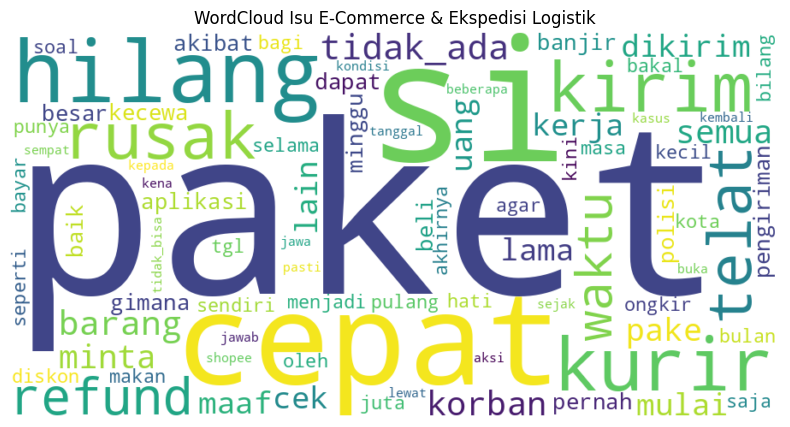

In [ ]:
# ==========================================
# @title 14. WORDCLOUD E-COMMERCE VS EKSPEDISI
# ==========================================

from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt
custom_stopwords = set(STOPWORDS)

custom_stopwords.update([
    'yang','dan','di','ke','dari','untuk','dengan','ini','itu','ada','hingga','juga','sama','aja','udah','sudah','nya','sih','gua',
    'jadi','hari','pada','dalam','orang','tersebut','indonesia','ga','gak','nggak','kok','banget','karena','saat','via','pun','ibu',
    'amp','rt','ya','aku','kalo','kalau','lebih','buat','lagi','baca','selengkapnya','bisa','akan','apa','saya','kita','tuh','air','tau',
    'kami','gue','gw','kak','min','dia','mereka','satu','dua','tiga','dulu','malah','semoga','tolong','biar','jg','dah','lah','ia',
    'cuma','setiap','sekarang','tahun','jam','rp','sampai','tapi','mau','kamu','express','langsung','setelah','sekarang','warga','pas',
    'kalian','anak','jakarta','jalan','banyak','kali','sini','pa','lu','gt','atas','sebagai','tanpa','selama''waktu','atau','seorang',
    'rumah','jangan','bikin','pakai','ternyata','kenapa','mana','mohon','salah','selalu','paling','yaa','t',

    # noise
    'pakai','kan','nih','gini','terus','tetap',
    'padahal','harus','masih','baru','lalu','j',

    # brand
    'lazada','tiktokshop',
    'jnt','jnt_express',
    'sicepat','sicepat_express'])

text = ' '.join(
    hasil[hasil['Sentiment']=='Negatif']['clean_text'])

wordcloud = WordCloud(
    width=900,
    height=450,
    background_color='white',
    stopwords=custom_stopwords,
    max_words=80,
    collocations=False,
    prefer_horizontal=0.9
).generate(text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('WordCloud Isu E-Commerce & Ekspedisi Logistik')
plt.show()

Silhouette Score: 0.5003


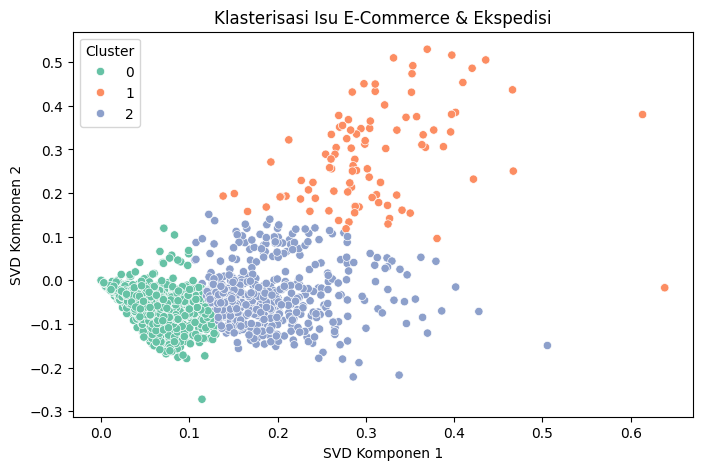


Cluster 0
['hilang', 'paket', 'rusak', 'telat', 'refund', 'uang', 'kecewa', 'semua', 'atas', 'kami']

Cluster 1
['kirim', 'paket', 'ongkir', 'diskon', 'aplikasi', 'seluruh', 'pengiriman', 'paketmu', 'promo', 'spesial']

Cluster 2
['paket', 'kurir', 'kirim', 'barang', 'hilang', 'dikirim', 'kak', 'resi', 'gratis', 'yuk']


In [ ]:
# ==========================================
# @title 15. KLASTERISASI ISU E-COMMERCE & EKSPEDISI
# ==========================================

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from collections import Counter

stop_kmeans = [
    'yang','dan','di','ke','dari','untuk','dengan','ini','itu','ada','jadi','aja','udah','sudah','aku','kamu','saya','kita','dia','mereka','nya','sih','ga','gak','nggak','karena','lebih',
    'lagi','baca','selengkapnya','via','amp','00','bisa','tapi','kalau','kalo','buat','ya','sampai','mau','dalam','pada','gt','2025','2026','rp','warga','seorang','banget','juga',
    'atau','1','2','3','5','40','masih','baru','kalian','setelah','sini','anak','lu','gw','gue','nih','gini','pake','pakai','jangan','kenapa','terima','mohon','tetap','padahal','lain',
    'makin','dapat','cek','salah','mulai','lalu','ternyata','hari','orang','semoga','biar','pas','si','j','t','min','sama','tolong','cepat','langsung','paling','terus','waktu',
    'akan','jalan','satu','rumah','setiap','hingga','berat','hemat','malah','tgl','harus','banyak','kan','apa','saat','tahun','indonesia','tersebut','korban','jakarta','bikin',

    # nama brand
    'lazada','tiktokshop','jnt','jnt_express','sicepat','sicepat_express','express']

df['clean_kmeans'] = df['clean_text'].copy()

for kata in stop_kmeans:
    df['clean_kmeans'] = df['clean_kmeans'].str.replace(
        rf'\b{kata}\b', '', regex=True)

vectorizer = TfidfVectorizer(max_features=1000)
X_tfidf = vectorizer.fit_transform(df['clean_kmeans'])

svd = TruncatedSVD(n_components=2, random_state=42)
X_2d = svd.fit_transform(X_tfidf)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_2d)

sil_score = silhouette_score(X_2d, df['Cluster'])
print("Silhouette Score:", round(sil_score, 4))

plt.figure(figsize=(8,5))

sns.scatterplot(
    x=X_2d[:,0],
    y=X_2d[:,1],
    hue=df['Cluster'],
    palette='Set2')

plt.title('Klasterisasi Isu E-Commerce & Ekspedisi')
plt.xlabel('SVD Komponen 1')
plt.ylabel('SVD Komponen 2')
plt.show()

for cluster_id in sorted(df['Cluster'].unique()):
    teks = ' '.join(df[df['Cluster']==cluster_id]['clean_kmeans'])
    top_words = Counter(teks.split()).most_common(10)

    print(f"\nCluster {cluster_id}")
    print([w for w,c in top_words])

In [ ]:
# ==========================================
# @title 16A. IMPLEMENTASI BERTOPIC
# ==========================================

!pip -q install bertopic umap-learn hdbscan

import pandas as pd
from bertopic import BERTopic
from umap import UMAP
from sklearn.feature_extraction.text import CountVectorizer
from nltk.corpus import stopwords
import nltk

nltk.download('stopwords', quiet=True)

brand_keywords = [
    'lazada','tiktokshop','tiktok shop',
    'jnt','jnt_express','j t','j&t',
    'sicepat','sicepat_express']

issue_keywords = [
    'paket','kurir','pengiriman','kirim','dikirim','resi',
    'refund','retur','komplain','hilang','rusak','telat',
    'terlambat','ongkir','diskon','promo','voucher',
    'aplikasi','cod','barang']

brand_pattern = '|'.join(brand_keywords)
issue_pattern = '|'.join(issue_keywords)

df_bert = df[
    df['clean_text'].str.contains(brand_pattern, case=False, na=False) &
    df['clean_text'].str.contains(issue_pattern, case=False, na=False)
].copy()

print("Jumlah data relevan BERTopic:", len(df_bert))

sample_df = df_bert.head(300)
docs = sample_df["clean_text"].astype(str).tolist()

umap_model = UMAP(
    n_neighbors=2,
    n_components=2,
    min_dist=0.1,
    metric="cosine")

indonesian_stopwords = stopwords.words('indonesian')
indonesian_stopwords.extend([
    'baca','selengkapnya','amp','rf','via','aja','udah','sih','banget','kak','min','gw','gue','nih','gini','ya',
    'orang','tahun','indonesia','jakarta','warga','korban','pemerintah','polisi','video','viral','gaza','iran',
    'trump','amerika','israel','banjir','jalan','kapal','uang','rp','2025','2026','gt','ll','99',

    'tolong','halo','kaga','kau','dimana','dah','pas','ku','ilang','up','gabisa','gimana','dong','loh','woyy',
    'guys','huhu','otw','drop','paketmu','customer','aktif','hubungi','sekarang','layanan','pelanggan',

    'lazada','tiktokshop','tiktok','shop','jnt','jnt_express','sicepat','sicepat_express','express'])

vectorizer_model = CountVectorizer(
    stop_words=indonesian_stopwords,
    min_df=1)

topic_model = BERTopic(
    umap_model=umap_model,
    vectorizer_model=vectorizer_model,
    calculate_probabilities=True)

topics, probs = topic_model.fit_transform(docs)

print("\nRingkasan Topik:\n")
print(topic_model.get_topic_info())

Jumlah data relevan BERTopic: 98


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]


Ringkasan Topik:

   Topic  Count                                      Name  \
0     -1     48  -1_paket_jntexpress_kurir_sicepatexpress   
1      0     24   0_paket_kirim_jntexpress_sicepatexpress   
2      1     13       1_jntexpress_paket_hilang_ekspedisi   
3      2     13                    2_paket_lu_sebulan_nya   

                                                                                       Representation  \
0  [paket, jntexpress, kurir, sicepatexpress, hilang, tidakada, tgl, diterima, dikirim, jntexpressid]   
1          [paket, kirim, jntexpress, sicepatexpress, diskon, ongkir, juta, hampers, kurir, aplikasi]   
2         [jntexpress, paket, hilang, ekspedisi, barang, dikirim, pengirim, pengembalian, duit, 700k]   
3                [paket, lu, sebulan, nya, shopee, customerservice, ekspedisi, intip, karna, keluhan]   

                                                                                                                                                     

In [ ]:
# ==========================================
# @title 16B. VISUALISASI IMPLEMENTASI BERT
# ==========================================

fig = topic_model.visualize_barchart(top_n_topics=4)
fig.show()

Jumlah data relevan LDA: 98


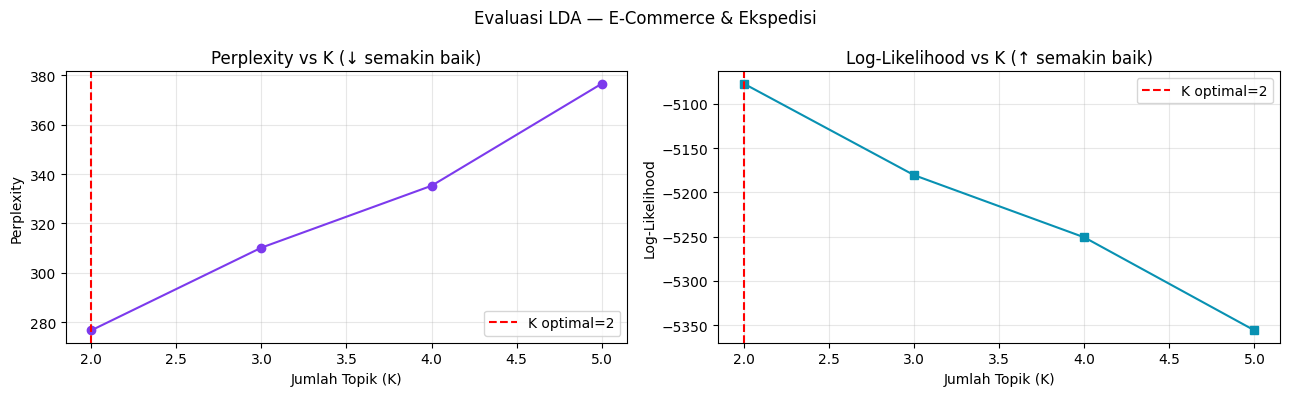

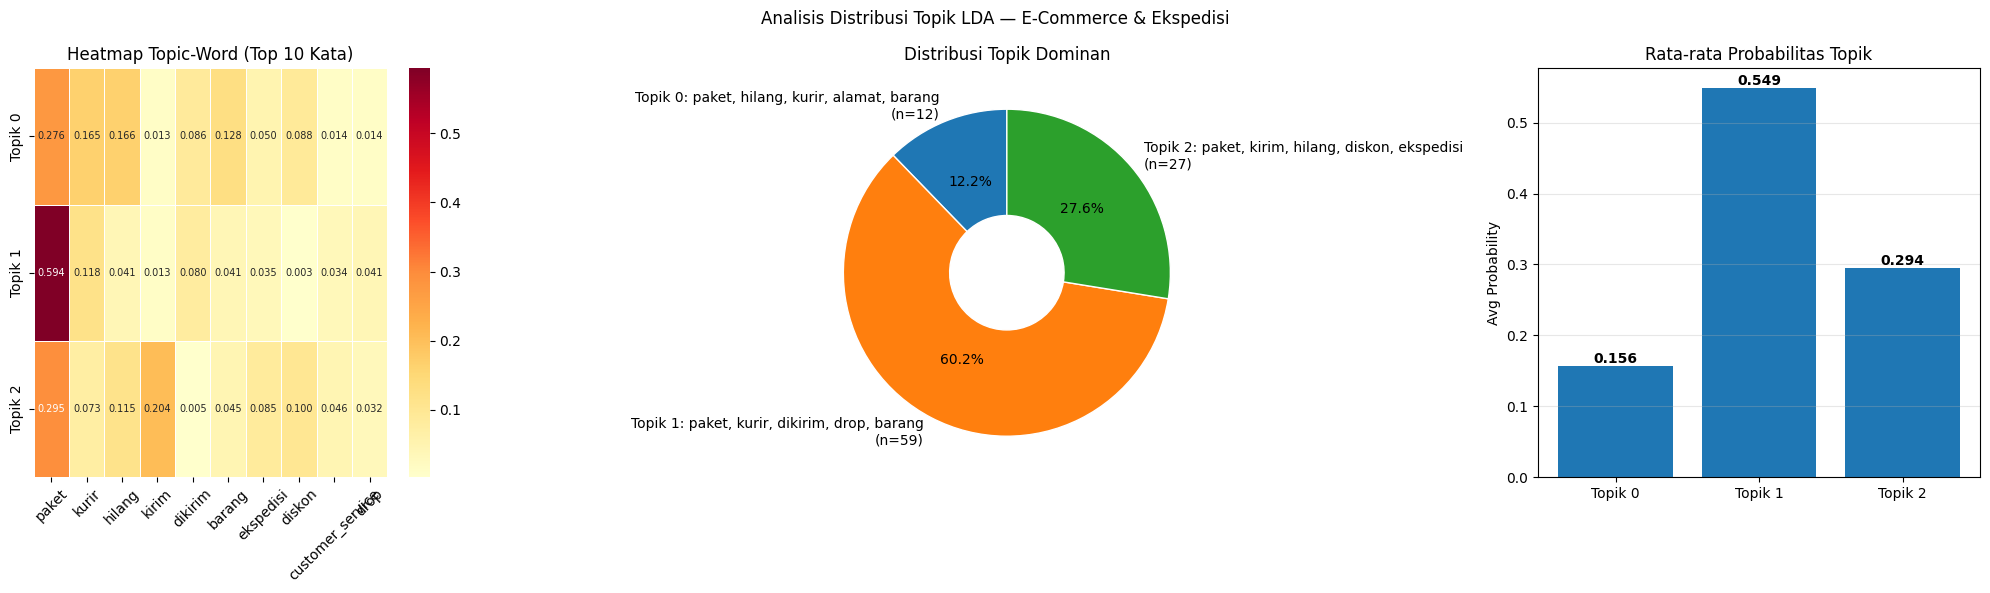

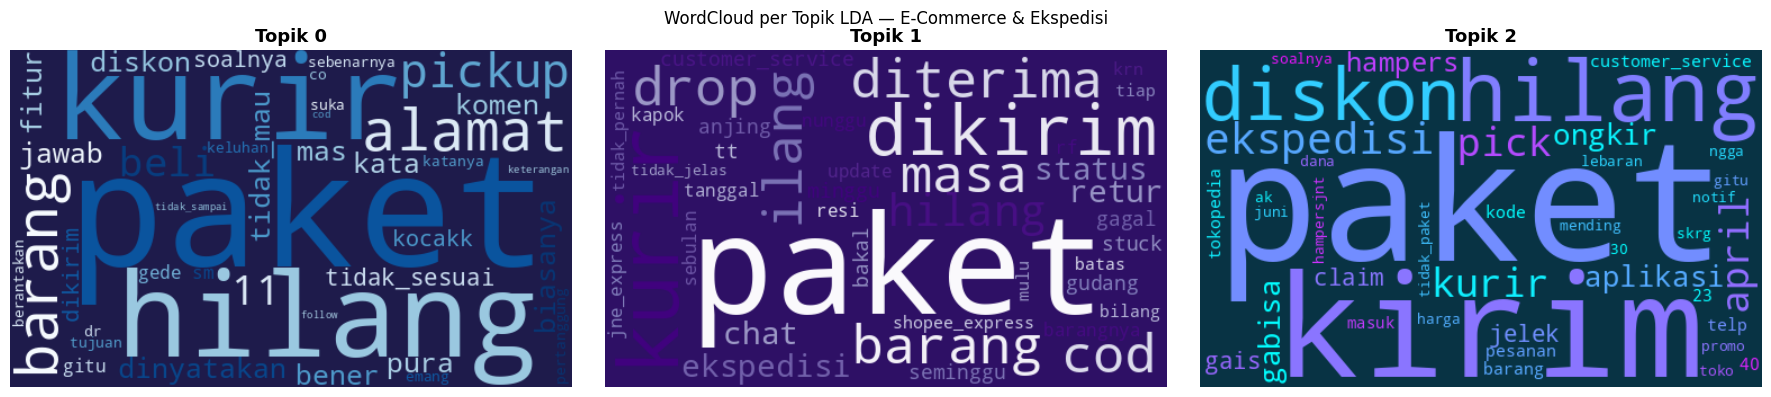

Ringkasan Topik LDA:
Topik 0: paket, hilang, kurir, alamat, barang, pickup, beli, 11, dinyatakan, biasanya
Topik 1: paket, kurir, dikirim, drop, barang, ilang, masa, diterima, cod, hilang
Topik 2: paket, kirim, hilang, diskon, ekspedisi, pick, april, kurir, aplikasi, gabisa


In [ ]:
# ==========================================
# @title 16C. LDA TOPIC MODELING E-COMMERCE & EKSPEDISI
# ==========================================

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from wordcloud import WordCloud

brand_keywords = [
    'lazada','tiktokshop','tiktok shop',
    'jnt','jnt_express','j t','j&t',
    'sicepat','sicepat_express']

issue_keywords = [
    'paket','kurir','pengiriman','kirim','dikirim','resi','refund','retur','komplain','hilang','rusak','telat',
    'terlambat','ongkir','diskon','promo','voucher','aplikasi','cod','barang']

brand_pattern = '|'.join(brand_keywords)
issue_pattern = '|'.join(issue_keywords)

df_lda = df[
    df['clean_text'].str.contains(brand_pattern, case=False, na=False) &
    df['clean_text'].str.contains(issue_pattern, case=False, na=False)
].copy()

print("Jumlah data relevan LDA:", len(df_lda))

stop_lda = [
    'yang','dan','di','ke','dari','untuk','dengan','ini','itu','ada','jadi','aja','udah','sudah','nya','sih','ga','gak','nggak','kok','banget','karena','saat','via','amp','rt','ya','aku',
    'kalo','kalau','lebih','buat','lagi','baca','selengkapnya','dalam','pada','akan','hari','tahun','2025','2026','gt','rp','sini','indonesia','pemerintah','polisi','korban',
    'seorang','tersebut','bisa','tapi','juga','sama','warga','jalan','banjir','viral','jakarta','kasus','atau','banyak','mau','masih','sampai','kerja','hingga','ia','atas',
    'setelah','dua','12','orang','juta','gratis','bantuan','baru','kini','sebagai','langsung','maaf','gw','gue','ll','kak','min','kami','kamu','mereka','pakai','nih','gini','terus',
    'waktu','semua','paling','jangan','cek','lain','dapat','lama','kecil','besar','bulan','saya','dia','apa','pas','si','kita','anak','semoga','biar','satu','yuk','malah',
    'pake','oleh','menjadi','lu','kau','halo','tolong','dimana','kaga','dah','jg','ku','tgl','tb2','voc','reply','customer','service','customerservice',
    'kalian','bikin','kenapa','mohon','gimana','program','terima','pun','harus','setiap','dulu','mana','cepat','rumah','10','jam','kan','jawa','akibat','tetap','tau','punya',
    'mulai','salah','padahal','cuma','sekarang','minta','00','yaa','uang','makan','lalu','selalu','pernah','makin','seluruh','up','jika','hati','seperti','tuh',
    'pulang','sendiri','kasih','presiden','buka','ternyata','bayar','tidak_ada','makanan','mbg','kembali','kali','agar','bagi','saja','dm','loh','no','kepada',
    'kota','soal','barat','sekolah','lah','beda','mei','kek','shopee','skin1004',

    # brand
    'lazada','tiktokshop','tiktok','shop',
    'jnt','jnt_express','jntexpress','jntexpressid',
    'sicepat','sicepat_express','sicepatexpress','express']

cv = CountVectorizer(
    max_features=300,
    min_df=1,
    max_df=0.95,
    stop_words=stop_lda)

X = cv.fit_transform(df_lda['clean_text'])
terms = cv.get_feature_names_out()

K_range = range(2, 6)
perplexities, log_likelihoods = [], []

for k in K_range:
    lda_tmp = LatentDirichletAllocation(
        n_components=k,
        max_iter=15,
        learning_method='online',
        random_state=42)

    lda_tmp.fit(X)
    perplexities.append(lda_tmp.perplexity(X))
    log_likelihoods.append(lda_tmp.score(X))

best_k = list(K_range)[perplexities.index(min(perplexities))]

fig, axes = plt.subplots(1, 2, figsize=(13,4))

axes[0].plot(list(K_range), perplexities, 'o-', color='#7C3AED')
axes[0].axvline(
    x=best_k,
    color='red',
    linestyle='--',
    label=f'K optimal={best_k}')

axes[0].set_title('Perplexity vs K (↓ semakin baik)')
axes[0].set_xlabel('Jumlah Topik (K)')
axes[0].set_ylabel('Perplexity')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(list(K_range), log_likelihoods, 's-', color='#0891B2')
axes[1].axvline(
    x=best_k,
    color='red',
    linestyle='--',
    label=f'K optimal={best_k}')

axes[1].set_title('Log-Likelihood vs K (↑ semakin baik)')
axes[1].set_xlabel('Jumlah Topik (K)')
axes[1].set_ylabel('Log-Likelihood')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('Evaluasi LDA — E-Commerce & Ekspedisi')
plt.tight_layout()
plt.show()

N_TOPICS = 3

lda = LatentDirichletAllocation(
    n_components=N_TOPICS,
    max_iter=30,
    learning_method='online',
    random_state=42)

lda.fit(X)

doc_topic_matrix = lda.transform(X)

df.loc[df_lda.index, 'dominant_topic'] = doc_topic_matrix.argmax(axis=1)
df.loc[df_lda.index, 'topic_prob'] = doc_topic_matrix.max(axis=1)

topic_labels = {}

for k in range(N_TOPICS):
    top_idx = lda.components_[k].argsort()[::-1][:5]
    top_words = [terms[i] for i in top_idx]
    topic_labels[k] = f"Topik {k}: {', '.join(top_words)}"

df.loc[df_lda.index, 'topic_label'] = df.loc[df_lda.index, 'dominant_topic'].map(topic_labels)

fig, axes = plt.subplots(1, 3, figsize=(20,6))

top_global_idx = lda.components_.sum(axis=0).argsort()[::-1][:10]
top_global_words = [terms[i] for i in top_global_idx]

heatmap_data = lda.components_[:, top_global_idx]
heatmap_norm = heatmap_data / heatmap_data.sum(axis=1, keepdims=True)

sns.heatmap(
    heatmap_norm,
    annot=True,
    fmt='.3f',
    cmap='YlOrRd',
    xticklabels=top_global_words,
    yticklabels=[f'Topik {k}' for k in range(N_TOPICS)],
    ax=axes[0],
    linewidths=0.5,
    annot_kws={'size':7})

axes[0].set_title('Heatmap Topic-Word (Top 10 Kata)')
axes[0].tick_params(axis='x', rotation=45)

topic_counts = pd.Series(doc_topic_matrix.argmax(axis=1)).value_counts().sort_index()

pie_labels = [
    f"{topic_labels.get(int(k), f'Topik {int(k)}')}\n(n={v})"
    for k, v in topic_counts.items()]

axes[1].pie(
    topic_counts.values,
    labels=pie_labels,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops=dict(width=0.65, edgecolor='white'))

axes[1].set_title('Distribusi Topik Dominan')

avg_topic_prob = doc_topic_matrix.mean(axis=0)

axes[2].bar(range(N_TOPICS), avg_topic_prob)
axes[2].set_xticks(range(N_TOPICS))
axes[2].set_xticklabels([f'Topik {k}' for k in range(N_TOPICS)])
axes[2].set_title('Rata-rata Probabilitas Topik')
axes[2].set_ylabel('Avg Probability')
axes[2].grid(axis='y', alpha=0.3)

for bar in axes[2].patches:
    axes[2].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f'{bar.get_height():.3f}',
        ha='center',
        va='bottom',
        fontweight='bold')

plt.suptitle('Analisis Distribusi Topik LDA — E-Commerce & Ekspedisi')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, N_TOPICS, figsize=(6*N_TOPICS,4))

bg_colors = ['#1e1b4b','#2e1065','#083344']
wc_colors = ['Blues','Purples','cool']

for topic_idx in range(N_TOPICS):
    top_idx = lda.components_[topic_idx].argsort()[::-1][:50]

    wc_dict = {
        terms[i]: float(lda.components_[topic_idx][i])
        for i in top_idx}

    wc = WordCloud(
        width=500,
        height=300,
        background_color=bg_colors[topic_idx % len(bg_colors)],
        colormap=wc_colors[topic_idx % len(wc_colors)],
        max_words=40,
        prefer_horizontal=0.9
    ).generate_from_frequencies(wc_dict)

    axes[topic_idx].imshow(wc, interpolation='bilinear')
    axes[topic_idx].axis('off')
    axes[topic_idx].set_title(
        f'Topik {topic_idx}',
        fontsize=13,
        fontweight='bold')

plt.suptitle('WordCloud per Topik LDA — E-Commerce & Ekspedisi')
plt.tight_layout()
plt.show()

print("Ringkasan Topik LDA:")

for k in range(N_TOPICS):
    top_idx = lda.components_[k].argsort()[::-1][:10]
    top_words = [terms[i] for i in top_idx]
    print(f"Topik {k}: {', '.join(top_words)}")

In [ ]:
# ==========================================
# @title 17A. PERSIAPAN AWAL SNA
# ==========================================

import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import re

df_sna = df.copy()

print("Jumlah data:", len(df_sna))

display(
    df_sna[
        ['brand','kategori','username','full_text']
    ].head())

Jumlah data: 1905


,brand,kategori,username,full_text
0,Lazada,E-Commerce,anggarasamvdr,"guys ini menarik banget, gue pernah mikir gini juga ""gara-gara dating apps ada yang rusak dalam memandang orang di sekitar"" \n\nkalian ngerasa gini juga ga? https://t.co/IsxExf6l14"
1,Lazada,E-Commerce,awrimaa,"ᅠ\nwoman to woman,\n\nstop kasih akses ke orang yang bikin kamu ragu sama diri sendiri. kamu terlalu cantik pas lagi damai, jangan rusak itu demi yang gak ngerti nilai kamu.\nᅠ"
2,Lazada,E-Commerce,ElysiaXBT,"Mata lo tiba-tiba kabur, berbayang, atau ada bintik hitam melayang? Jangan buru-buru salahkan minus atau capek doang.\n\nDiabetes itu sering muncul di organ yang udah mulai rusak duluan, bukan di darah. Gini cara baca sinyal aslinya:\n\n1. Mata biasanya yang pertama kena."
3,Lazada,E-Commerce,kompascom,"""Situasi ekonomi keluarga yang hancur pasca-banjir berpotensi besar memaksa anak-anak putus sekolah karena masalah biaya. Di samping itu, alasan putus sekolah juga karena membangun sekolah rusak berat butuh waktu yang panjang,"" kata Ubaid, selaku Koordinator Nasional Jaringan https://t.co/bb0Ji28PR6"
4,Lazada,E-Commerce,jakmall,Jangan lupa lihat suppliernya.\n\nkalau suppliernya:\n❌ sering kosong\n❌ lama kirim\n❌ respon lambat\n\nyang dimarahin pembeli tetap kamu.


In [ ]:
# ==========================================
# @title 17B. EDGE LIST & EXPORT GEPHI
# ==========================================

edges = []

for i, row in df_sna.iterrows():

    mentions = re.findall(
        r"@(\w+)",
        str(row["full_text"]))

    for mention in mentions:

        edges.append([
            row["username"],
            mention,
            row["brand"],
            row["kategori"]])

edge_df = pd.DataFrame(
    edges,
    columns=[
        "Source",
        "Target",
        "Brand",
        "Kategori"])

print("Jumlah relasi mention:", len(edge_df))

display(edge_df.head())

edge_df.to_csv(
    "edge_list_ecommerce_ekspedisi.csv",
    index=False)

G = nx.from_pandas_edgelist(
    edge_df,
    source="Source",
    target="Target",
    create_using=nx.DiGraph())

print("\nJumlah Node :", G.number_of_nodes())
print("Jumlah Edge :", G.number_of_edges())

nx.write_gexf(
    G,
    "ecommerce_ekspedisi_sna.gexf")

print("\nFile ecommerce_ekspedisi_sna.gexf berhasil dibuat")

Jumlah relasi mention: 913


,Source,Target,Brand,Kategori
0,bontengatah,rumahsenja_,Lazada,E-Commerce
1,ShopeeID,ziwonist_,Lazada,E-Commerce
2,ShopeeID,ShopeeCare,Lazada,E-Commerce
3,ShopeeID,ShopeeCare,Lazada,E-Commerce
4,ShopeeID,ryuticc,Lazada,E-Commerce



Jumlah Node : 928
Jumlah Edge : 778

File ecommerce_ekspedisi_sna.gexf berhasil dibuat


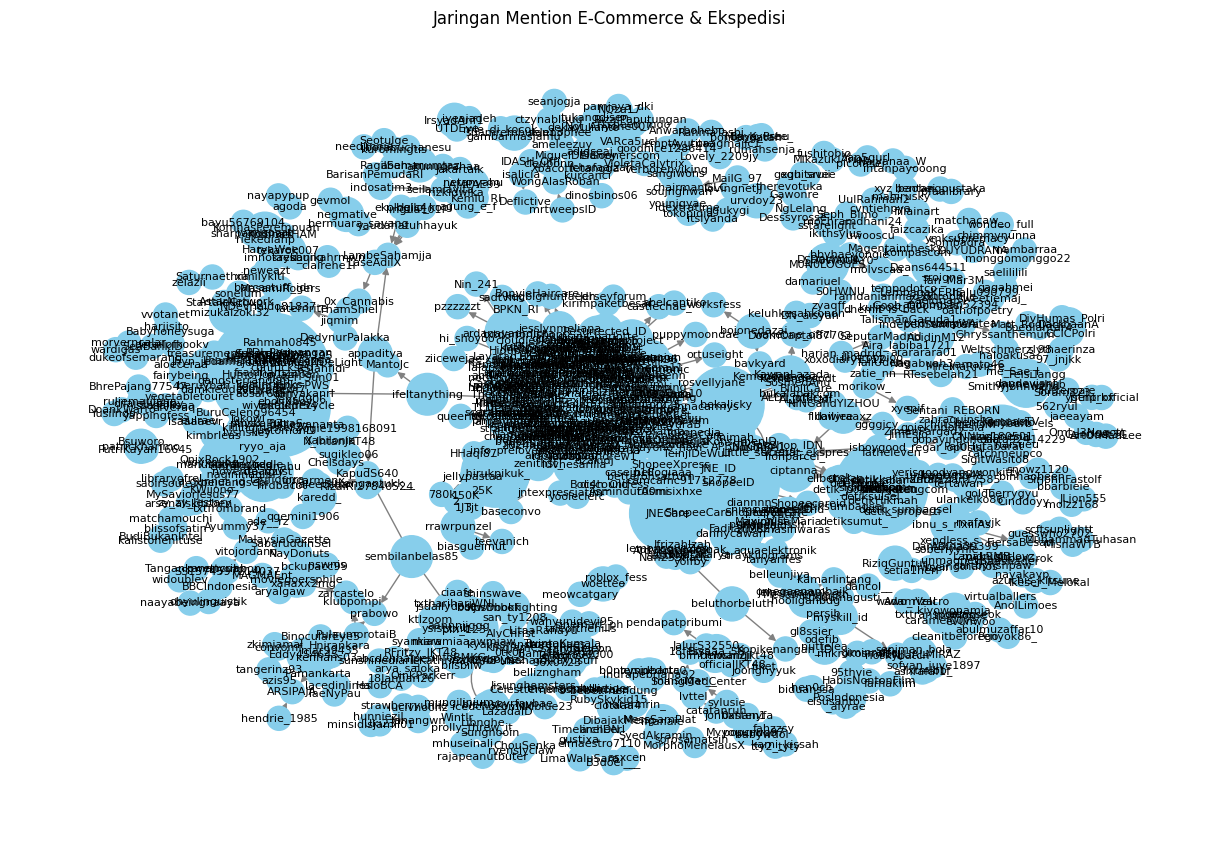

In [ ]:
# ==========================================
# @title 18. VISUALISASI GRAPH JEJARING
# ==========================================

plt.figure(figsize=(12,8))

pos = nx.spring_layout(
    G,
    k=0.5,
    seed=42)

node_sizes = [
    max(
        300,
        len(list(G.neighbors(n))) * 300)
    for n in G.nodes]

nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=node_sizes,
    node_color="skyblue",
    font_size=8,
    edge_color="gray",
    arrows=True,
    arrowsize=10)

plt.title(
    "Jaringan Mention E-Commerce & Ekspedisi")

plt.show()

In [ ]:
# ==========================================
# @title 19. HITUNG METRIK CENTRALITY
# ==========================================

degree_centrality = nx.degree_centrality(G)
betweenness_centrality = nx.betweenness_centrality(G)

try:
    eigenvector_centrality = nx.eigenvector_centrality(
        G, max_iter=1000)
except nx.PowerIterationFailedConvergence:
    eigenvector_centrality = {}

print("Top pengguna (Degree Centrality):")
print(
    sorted(
        degree_centrality.items(), key=lambda x: x[1], reverse=True)[:5])

print("\nTop pengguna (Betweenness Centrality):")
print(
    sorted(
        betweenness_centrality.items(), key=lambda x: x[1], reverse=True)[:5])

print("\nTop pengguna (Eigenvector Centrality):")
print(
    sorted(
        eigenvector_centrality.items(), key=lambda x: x[1], reverse=True)[:5])

Top pengguna (Degree Centrality):
[('jntexpressid', 0.2610571736785329), ('ShopeeID', 0.02804746494066882), ('fsaidhamzah', 0.02804746494066882), ('wiyantokdr54', 0.020496224379719524), ('detikcom', 0.016181229773462782)]

Top pengguna (Betweenness Centrality):
[('jntexpressid', 0.0008410977607228315), ('ShopeeID', 0.00013979464167138472), ('pln_123', 1.863928555618463e-05), ('Telkomsel', 1.3979464167138473e-05), ('fsaidhamzah', 1.3979464167138473e-05)]

Top pengguna (Eigenvector Centrality):
[('jntexpressid', 0.6826878856423119), ('jtcargoid', 0.4218755567403689), ('dewantara_adhi', 0.42187555648928127), ('tomorocoffee', 0.42187555648928127), ('tokopedia', 0.0001276542604207921)]


In [ ]:
# ==========================================
# @title SNA PRIORITAS (TOP ACCOUNT)
# ==========================================

import networkx as nx

# hitung centrality
betweenness = nx.betweenness_centrality(G)

# ambil 20 akun paling penting
top_accounts = (
    pd.DataFrame(
        betweenness.items(),
        columns=['Akun','Betweenness']
    )
    .sort_values(
        'Betweenness',
        ascending=False
    )
    .head(20)
)

display(top_accounts)

,Akun,Betweenness
86,jntexpressid,0.000841
2,ShopeeID,0.000140
65,pln_123,0.000019
708,fsaidhamzah,0.000014
31,Telkomsel,0.000014
246,JNECare,0.000010
49,MediaKonsumenID,0.000007
748,wiyantokdr54,0.000006
212,shin_977,0.000005
521,tekarok007,0.000002


In [ ]:
!pip install python-louvain

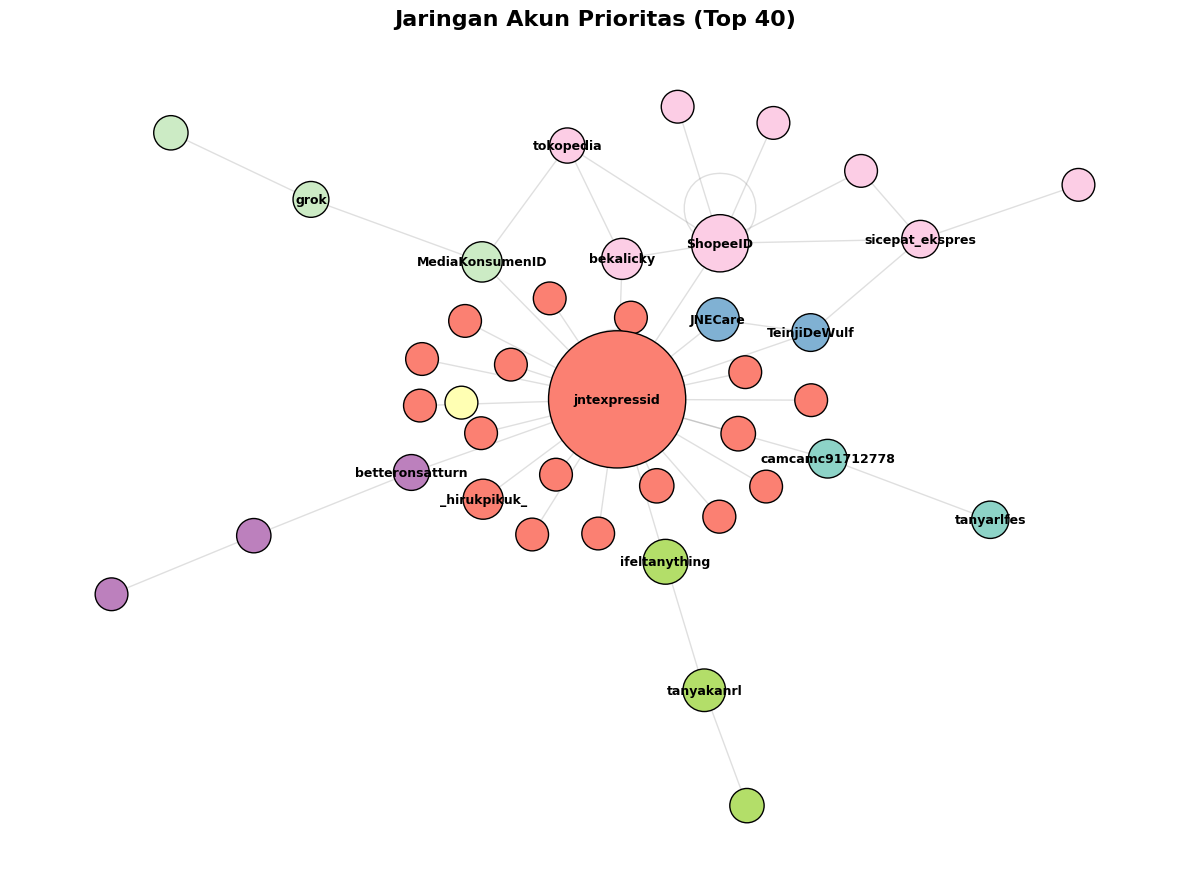

In [ ]:
# ==========================================
# VISUALISASI SNA AKUN PRIORITAS
# ==========================================

import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
import community.community_louvain as community_louvain
import matplotlib.cm as cm

# load edge list
edge_df = pd.read_csv('edge_list_ecommerce_ekspedisi.csv')

# graph
G = nx.from_pandas_edgelist(
    edge_df,
    source='Source',
    target='Target'
)

# betweenness
betweenness = nx.betweenness_centrality(G)

top_accounts = (
    pd.DataFrame(
        betweenness.items(),
        columns=['Akun','Betweenness']
    )
    .sort_values(
        'Betweenness',
        ascending=False
    )
    .head(40)
)

top_nodes = top_accounts['Akun'].tolist()

# ambil subgraph
G_top = G.subgraph(top_nodes)

# community detection
partition = community_louvain.best_partition(G_top)

# layout
pos = nx.kamada_kawai_layout(G_top)

# warna komunitas
communities = list(set(partition.values()))
colors = cm.Set3(
    [i/len(communities) for i in range(len(communities))]
)

color_map = {
    com: colors[i]
    for i, com in enumerate(communities)
}

node_colors = [
    color_map[partition[node]]
    for node in G_top.nodes()
]

# ukuran node
node_sizes = [
    betweenness[node]*70000 + 500
    for node in G_top.nodes()
]

plt.figure(figsize=(12,9))

# edge
nx.draw_networkx_edges(
    G_top,
    pos,
    alpha=0.25,
    edge_color='gray',
    width=1
)

# node
nx.draw_networkx_nodes(
    G_top,
    pos,
    node_size=node_sizes,
    node_color=node_colors,
    edgecolors='black',
    linewidths=1
)

# label hanya 15 akun teratas
top15 = top_accounts.head(15)['Akun']

labels = {
    node: node
    for node in G_top.nodes()
    if node in top15.values
}

nx.draw_networkx_labels(
    G_top,
    pos,
    labels,
    font_size=9,
    font_weight='bold'
)

plt.title(
    "Jaringan Akun Prioritas (Top 40)",
    fontsize=16,
    fontweight='bold'
)

plt.axis('off')
plt.tight_layout()
plt.show()

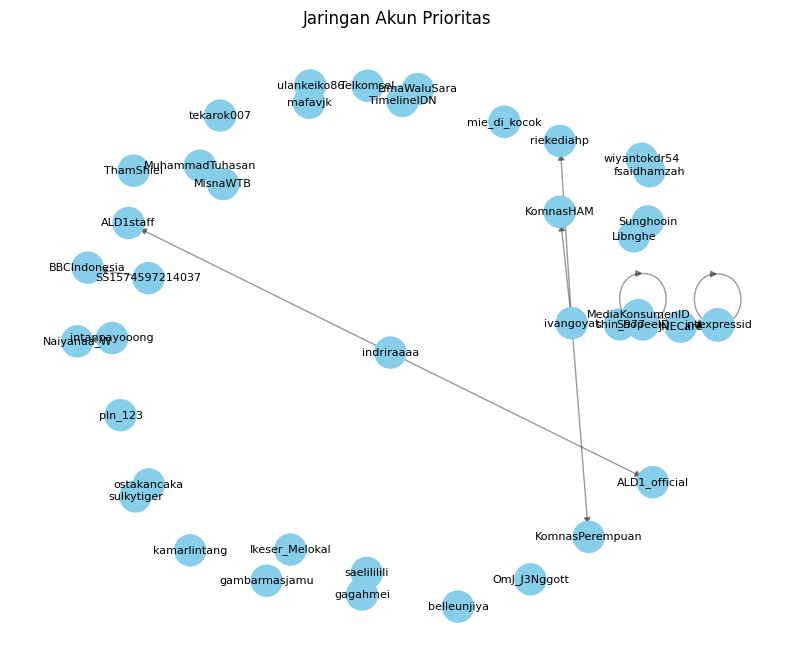

In [ ]:
# ambil node penting

import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt

# Load edge_df to ensure it's available
edge_df = pd.read_csv('edge_list_ecommerce_ekspedisi.csv')

# Recreate graph G from edge_df
G = nx.from_pandas_edgelist(
    edge_df,
    source="Source",
    target="Target",
    create_using=nx.DiGraph())

# Recalculate betweenness and top_accounts to ensure they are defined
betweenness = nx.betweenness_centrality(G)

top_accounts = (
    pd.DataFrame(
        betweenness.items(),
        columns=['Akun','Betweenness']
    )
    .sort_values(
        'Betweenness',
        ascending=False
    )
    .head(40)
)

top_nodes = top_accounts['Akun'].tolist()

G_top = G.subgraph(top_nodes)

plt.figure(figsize=(10,8))

pos = nx.spring_layout(
    G_top,
    seed=42
)

node_size = [
    betweenness[n]*50000 + 500
    for n in G_top.nodes()
]

nx.draw_networkx_nodes(
    G_top,
    pos,
    node_size=node_size,
    node_color='skyblue'
)

nx.draw_networkx_edges(
    G_top,
    pos,
    alpha=0.4
)

nx.draw_networkx_labels(
    G_top,
    pos,
    font_size=8
)

plt.title(
    "Jaringan Akun Prioritas"
)

plt.axis('off')
plt.show()

In [ ]:
# ==========================================
# @title 19A. HITUNG METRIK CENTRALITY [Tabel]
# ==========================================

degree_centrality = nx.degree_centrality(G)
betweenness_centrality = nx.betweenness_centrality(G)

try:
    eigenvector_centrality = nx.eigenvector_centrality(
        G,
        max_iter=1000
    )
except nx.PowerIterationFailedConvergence:
    eigenvector_centrality = {}

centrality_df = pd.DataFrame({
    'Akun': list(G.nodes()),
    'Degree_Centrality': [
        degree_centrality.get(node, 0)
        for node in G.nodes()
    ],
    'Betweenness_Centrality': [
        betweenness_centrality.get(node, 0)
        for node in G.nodes()
    ],
    'Eigenvector_Centrality': [
        eigenvector_centrality.get(node, 0)
        for node in G.nodes()
    ]
})

centrality_df = centrality_df.sort_values(
    by='Betweenness_Centrality',
    ascending=False
)

display(centrality_df.head(20))

centrality_df.to_csv(
    "centrality_ecommerce_ekspedisi.csv",
    index=False
)

,Akun,Degree_Centrality,Betweenness_Centrality,Eigenvector_Centrality
86,jntexpressid,0.261057,0.000841,6.826879e-01
2,ShopeeID,0.028047,0.000140,1.276530e-04
65,pln_123,0.010787,0.000019,1.711961e-10
708,fsaidhamzah,0.028047,0.000014,1.595663e-05
31,Telkomsel,0.007551,0.000014,2.548920e-10
246,JNECare,0.011866,0.000010,8.750024e-11
49,MediaKonsumenID,0.005394,0.000007,8.750024e-11
748,wiyantokdr54,0.020496,0.000006,1.595663e-05
212,shin_977,0.002157,0.000005,8.750024e-11
521,tekarok007,0.003236,0.000002,8.750024e-11


In [ ]:
# ==========================================
# @title EXPORT DATA UNTUK STREAMLIT
# ==========================================

df.to_csv("uas_ecommercekspedisi.csv", index=False)
edge_df.to_csv("edge_list_ecommerce_ekspedisi.csv", index=False)

# kalau centrality belum jadi dataframe, buat dulu
centrality_df = pd.DataFrame({
    "Akun": list(G.nodes()),
    "Degree_Centrality": [degree_centrality.get(n, 0) for n in G.nodes()],
    "Betweenness_Centrality": [betweenness_centrality.get(n, 0) for n in G.nodes()],
    "Eigenvector_Centrality": [eigenvector_centrality.get(n, 0) for n in G.nodes()]})

centrality_df = centrality_df.sort_values(
    by="Betweenness_Centrality",
    ascending=False)

centrality_df.to_csv("centrality_ecommerce_ekspedisi.csv", index=False)

print("File untuk Streamlit berhasil dibuat")

File untuk Streamlit berhasil dibuat


In [ ]:
# ==========================================
# EXPORT DATA UNTUK DASHBOARD
# ==========================================

df.to_csv(
    "hasil_utama.csv",
    index=False)

print("hasil_utama.csv berhasil disimpan")

hasil_utama.csv berhasil disimpan


In [ ]:
df.columns

Index(['conversation_id_str', 'created_at', 'favorite_count', 'full_text',
       'id_str', 'image_url', 'in_reply_to_screen_name', 'lang', 'location',
       'quote_count', 'reply_count', 'retweet_count', 'tweet_url',
       'user_id_str', 'username', 'brand', 'kategori', 'clean_text', 'tokens',
       'Sentiment_Score', 'Sentiment', 'clean_kmeans', 'Cluster',
       'dominant_topic', 'topic_prob', 'topic_label'],
      dtype='object')

In [ ]:
top_accounts.to_csv(
    "top_accounts.csv",
    index=False)

In [ ]:
top_accounts.columns

Index(['Akun', 'Betweenness'], dtype='object')

In [ ]:
edge_df.to_csv(
    "edge_list.csv",
    index=False)

In [ ]:
issue_df.to_csv(
    "issue.csv",
    index=False)

In [ ]:
issue_df.columns

Index(['Kategori', 'Isu', 'Jumlah'], dtype='object')

In [ ]:
edge_df.to_csv(
    "edge_list_ecommerce_ekspedisi.csv",
    index=False
)

In [ ]:
issue_df.to_csv(
    "issue_df.csv",
    index=False
)

In [ ]:
print(issue_df.columns)
print(top_accounts.columns)

Index(['Kategori', 'Isu', 'Jumlah'], dtype='object')
Index(['Akun', 'Betweenness'], dtype='object')


In [ ]:
import pandas as pd
import json

hasil = pd.read_csv("hasil_utama.csv")
issue = pd.read_csv("issue.csv")
accounts = pd.read_csv("top_accounts.csv")

In [ ]:
brand_sentiment = (
    hasil.groupby(["brand","Sentiment"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

brand_sentiment.columns.name = None

brand_sentiment = brand_sentiment.rename(columns={
    "brand":"brand"
})

brand_sentiment = brand_sentiment.to_dict("records")

In [ ]:
sentiment_summary = (
    hasil["Sentiment"]
    .value_counts()
    .reset_index()
)

sentiment_summary.columns = ["Sentiment","Jumlah"]

sentiment_summary = sentiment_summary.to_dict("records")

In [ ]:
topics = (
    hasil.groupby(["dominant_topic","topic_label"])
    .size()
    .reset_index(name="Jumlah")
)

topics = topics.rename(columns={
    "dominant_topic":"Topik",
    "topic_label":"Interpretasi"
})

topics["Kata Kunci"] = topics["Interpretasi"]

topics = topics.to_dict("records")

In [ ]:
accounts = accounts.rename(columns={
    "Betweenness":"Degree_Centrality"
})

centrality = accounts.to_dict("records")

In [ ]:
raw = hasil.rename(columns={
    "created_at":"Tanggal",
    "brand":"Brand",
    "kategori":"Kategori",
    "username":"Akun",
    "full_text":"Tweet"
})

raw["Isu"] = ""

raw = raw.to_dict("records")

In [ ]:
dashboard = {
    "brandSentiment": brand_sentiment,
    "sentimentSummary": sentiment_summary,
    "topIssues": issue.to_dict("records"),
    "ldaTopics": topics,
    "centralityTop": centrality,
    "rawTweets": raw
}

In [ ]:
with open(
    "dashboard_data.json",
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        dashboard,
        f,
        indent=4,
        ensure_ascii=False
    )

In [ ]:
import numpy as np

def clean_nan(obj):
    if isinstance(obj, dict):
        return {k: clean_nan(v) for k, v in obj.items()}
    elif isinstance(obj, list):
        return [clean_nan(v) for v in obj]
    elif pd.isna(obj):
        return None
    return obj

dashboard = clean_nan(dashboard)

In [ ]:
with open(
    "dashboard_data.json",
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        dashboard,
        f,
        indent=4,
        ensure_ascii=False
    )

In [ ]:
sentiment_summary = hasil['Sentiment'].value_counts().reset_index()
sentiment_summary.columns = ['Sentiment', 'Jumlah']

In [ ]:
brand_sentiment = hasil.groupby(['brand', 'Sentiment']).size().unstack(fill_value=0).reset_index()

In [ ]:
overview = {
    "total_tweet": len(hasil),
    "positif": (hasil['Sentiment'] == 'Positif').sum(),
    "negatif": (hasil['Sentiment'] == 'Negatif').sum(),
    "netral": (hasil['Sentiment'] == 'Netral').sum(),
    "akun_unik": hasil['username'].nunique()
}

In [ ]:
top_issues = hasil['clean_text'].str.extract(
    '(paket|kurir|refund|komplain|retur|hilang|rusak|telat|stuck|lama)',
    expand=False
).value_counts().reset_index()

top_issues.columns = ['Isu', 'Jumlah']

In [ ]:
import json
import numpy as np

# Convert numpy.int64 values in overview to standard Python integers
cleaned_overview = {}
for k, v in overview.items():
    if isinstance(v, np.int64):
        cleaned_overview[k] = int(v)
    else:
        cleaned_overview[k] = v

dashboard_data = {
    "overview": cleaned_overview,
    "brandSentiment": brand_sentiment.to_dict(orient='records'),
    "sentimentSummary": sentiment_summary.to_dict(orient='records'),
    "topIssues": top_issues.to_dict(orient='records')
}

with open("dashboard_data.json", "w", encoding="utf-8") as f:
    json.dump(dashboard_data, f, indent=2, ensure_ascii=False)